# Exercise 3 — Preparing Real-World Data for a Neural Network

Pré-processamento do [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)
(`train.csv`, o único arquivo rotulado) para uma rede com ativação `tanh` nas camadas
escondidas. Todas as estatísticas de transformação são ajustadas **apenas no treino**.

Semente fixa: `random_state = 42` no split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

SEED = 42
df = pd.read_csv("spaceship-titanic/train.csv")
print("shape bruto:", df.shape)
df.head()

shape bruto: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## A — Get to know the data

**Objetivo do dataset.** Cada linha é um passageiro da nave; a coluna-alvo
`Transported` indica se ele foi transportado para outra dimensão na colisão com a
anomalia espaço-temporal. É um problema de **classificação binária**.

In [2]:
balance = df["Transported"].value_counts()
print(balance.to_string())
print(f"\nProporção da classe positiva (True): {df['Transported'].mean():.4f}")

Transported
True     4378
False    4315

Proporção da classe positiva (True): 0.5036


**Balanço de classes:** 4378 `True` × 4315 `False` — a classe positiva representa
**50.36%** das 8693 amostras. O dataset é praticamente balanceado.

**Features** (descartando os identificadores `PassengerId`, `Name` e `Cabin`):

| Tipo | Colunas |
|---|---|
| Numéricas | `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` |
| Categóricas | `HomePlanet`, `CryoSleep`, `Destination`, `VIP` |

In [3]:
SPEND = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUM = ["Age"] + SPEND
CAT = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

# Tabela de missing values por coluna
missing = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "%": (df.isna().mean() * 100).round(2),
}).sort_values("faltantes", ascending=False)
missing

,faltantes,%
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


Todas as colunas de entrada têm entre **179 e 217** valores faltantes
(**2.06% a 2.50%** cada); apenas `PassengerId` e `Transported` estão completas.

In [4]:
# Estatísticas das colunas de gasto (dataset completo, apenas descrição — nada é fitado aqui)
spend_stats = df[SPEND].agg(["mean", "median", "max"]).round(2)
spend_stats

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
mean,224.69,458.08,173.73,311.14,304.85
median,0.00,0.00,0.00,0.00,0.00
max,14327.00,29813.00,23492.00,22408.00,24133.00


**Média × mediana.** A mediana das cinco colunas de gasto é **0** — mais da metade
dos passageiros não gastou nada — enquanto as médias vão de 173.73 (`ShoppingMall`)
a 458.08 (`FoodCourt`) e os máximos chegam a 29813. Média muito acima da mediana é a
assinatura de distribuições com **forte assimetria à direita (cauda pesada)**: poucos
passageiros com gastos altíssimos puxam a média, e a dispersão é dominada por esses
extremos.

## B — Split before you transform

In [5]:
X = df.drop(columns=["Transported", "Cabin", "Name", "PassengerId"])
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"treino: {X_train.shape} | teste: {X_test.shape}")
print(f"proporção True — treino: {y_train.mean():.4f} | teste: {y_test.mean():.4f}")

treino: (6954, 10) | teste: (1739, 10)
proporção True — treino: 0.5036 | teste: 0.5037


Split **80/20 estratificado** pelo alvo com semente fixa: 6954 amostras de treino e
1739 de teste, ambas com 50.4% de classe positiva.

**Por que o split vem antes?** O conjunto de teste simula dados que o modelo nunca
viu. Se qualquer estatística de transformação (mediana para imputação, mínimo/máximo
para escala, categorias observadas) for calculada com o dataset completo, informação
do teste vaza para dentro do pré-processamento e a avaliação deixa de ser confiável
(*data leakage*). Por isso todo `fit` daqui em diante usa somente o treino, e o teste
recebe apenas `transform`.

## C — Preprocess

In [6]:
# --- Missing data: mediana nas numéricas, moda nas categóricas (fit só no treino) ---
imp_num = SimpleImputer(strategy="median").fit(X_train[NUM])
imp_cat = SimpleImputer(strategy="most_frequent").fit(X_train[CAT])

Xtr_num = pd.DataFrame(imp_num.transform(X_train[NUM]), columns=NUM, index=X_train.index)
Xte_num = pd.DataFrame(imp_num.transform(X_test[NUM]), columns=NUM, index=X_test.index)
Xtr_cat = pd.DataFrame(imp_cat.transform(X_train[CAT]), columns=CAT, index=X_train.index)
Xte_cat = pd.DataFrame(imp_cat.transform(X_test[CAT]), columns=CAT, index=X_test.index)

print("medianas (treino):", dict(zip(NUM, imp_num.statistics_)))
print("modas (treino):   ", dict(zip(CAT, imp_cat.statistics_)))

medianas (treino): {'Age': np.float64(27.0), 'RoomService': np.float64(0.0), 'FoodCourt': np.float64(0.0), 'ShoppingMall': np.float64(0.0), 'Spa': np.float64(0.0), 'VRDeck': np.float64(0.0)}
modas (treino):    {'HomePlanet': 'Earth', 'CryoSleep': False, 'Destination': 'TRAPPIST-1e', 'VIP': False}


**Justificativa.** Nas numéricas, a **mediana** é robusta às caudas pesadas vistas no
item A (a média seria puxada pelos extremos); na prática ela imputa `Age = 27` e
gasto `0`, o valor típico. Nas categóricas, a **moda** preserva a categoria mais
frequente sem inventar níveis novos.

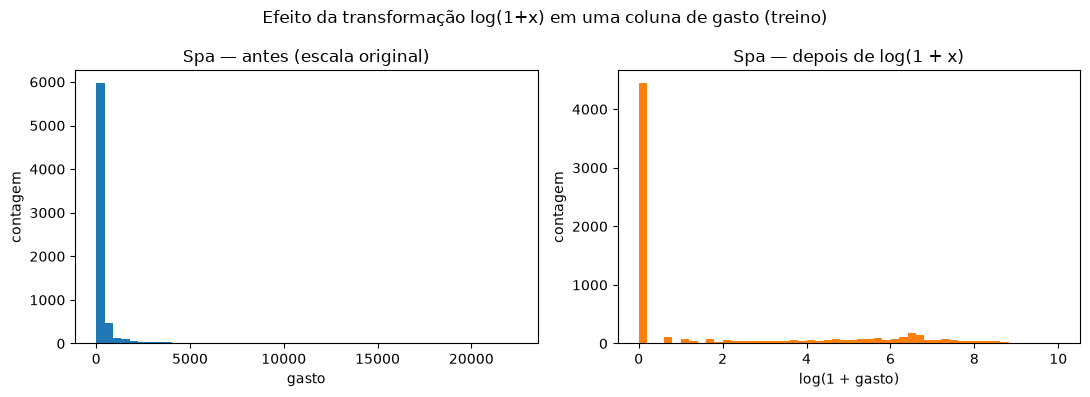

In [7]:
# --- Feature engineering: TotalSpend (após a imputação, para não somar NaN) ---
for d in (Xtr_num, Xte_num):
    d["TotalSpend"] = d[SPEND].sum(axis=1)

# --- Caudas pesadas: log(1 + x) nos gastos e no TotalSpend ---
LOG_COLS = SPEND + ["TotalSpend"]
spa_before = Xtr_num["Spa"].copy()          # guardado para o histograma
for d in (Xtr_num, Xte_num):
    d[LOG_COLS] = np.log1p(d[LOG_COLS])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(spa_before, bins=50, color="tab:blue")
axes[0].set_title("Spa — antes (escala original)")
axes[0].set_xlabel("gasto")
axes[1].hist(Xtr_num["Spa"], bins=50, color="tab:orange")
axes[1].set_title("Spa — depois de log(1 + x)")
axes[1].set_xlabel("log(1 + gasto)")
for ax in axes:
    ax.set_ylabel("contagem")
fig.suptitle("Efeito da transformação log(1+x) em uma coluna de gasto (treino)")
plt.tight_layout()
plt.show()

**Por que o log ajuda com `tanh`?** Sem ele, os máximos na casa de dezenas de
milhares dominam qualquer escala: após normalizar, a imensa maioria dos pontos fica
comprimida num intervalo minúsculo e os extremos caem na região onde o `tanh` satura
(derivada ≈ 0), travando o gradiente. O `log(1+x)` comprime a cauda e espalha a massa
de dados pela faixa útil da ativação, mantendo `0 → 0`.

In [8]:
# --- Categóricas: one-hot (fit só no treino) ---
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(Xtr_cat)
Etr = enc.transform(Xtr_cat)
Ete = enc.transform(Xte_cat)
print("categorias aprendidas no treino:")
for c, cats in zip(CAT, enc.categories_):
    print(f"  {c}: {list(cats)}")

categorias aprendidas no treino:
  HomePlanet: ['Earth', 'Europa', 'Mars']
  CryoSleep: [False, True]
  Destination: ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
  VIP: [False, True]


**Categoria que só aparece no teste:** com `handle_unknown="ignore"`, um nível não
visto no treino é codificado como **vetor todo-zeros** naquele grupo de colunas — o
pipeline não quebra e nenhuma categoria do teste cria coluna nova. (Neste dataset as
categorias coincidem entre treino e teste, mas a garantia vale em geral.)

In [9]:
# --- Escala: normalização para [-1, 1] nas numéricas (fit só no treino) ---
scaler = MinMaxScaler(feature_range=(-1, 1)).fit(Xtr_num)
Str = scaler.transform(Xtr_num)
Ste = scaler.transform(Xte_num)

# matriz final = numéricas escaladas + one-hot (one-hot já está em {0, 1} ⊂ [-1, 1])
feature_names = list(Xtr_num.columns) + list(enc.get_feature_names_out(CAT))
X_train_final = np.hstack([Str, Etr])
X_test_final = np.hstack([Ste, Ete])

print(f"treino — min: {X_train_final.min():.4f} | max: {X_train_final.max():.4f}")
print(f"teste  — min: {X_test_final.min():.4f} | max: {X_test_final.max():.4f}")

treino — min: -1.0000 | max: 1.0000
teste  — min: -1.0000 | max: 1.1383


**Escolha da escala.** Normalização para $[-1, 1]$ (`MinMaxScaler`), a faixa nativa
do `tanh`. No **treino** o resultado é exatamente $[-1.0000,\ 1.0000]$. No **teste**
o máximo chega a **1.1383** (`ShoppingMall` e `VRDeck` têm valores acima do máximo
visto no treino) — consequência esperada de ajustar a escala só no treino, e evidência
de que não houve vazamento; o leve estouro não afeta o `tanh`, que aceita qualquer
valor real.

## D — Verify and visualize

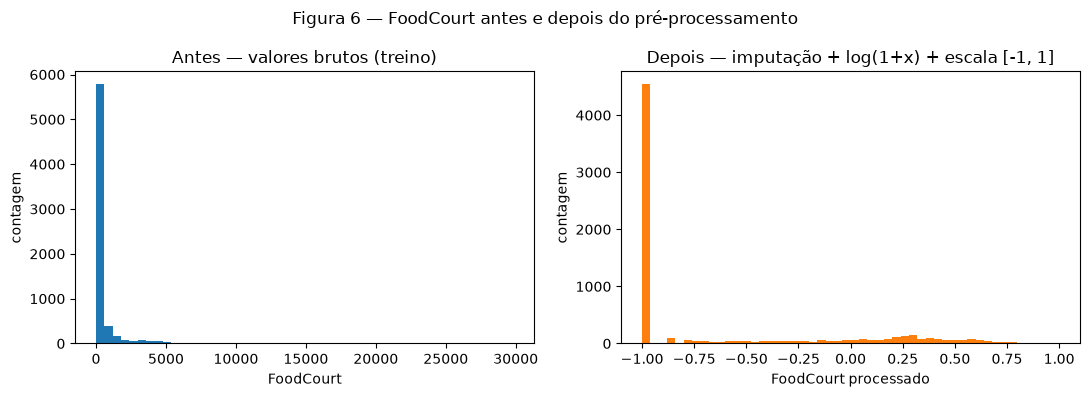

In [10]:
# Figura 6 — FoodCourt antes (bruto) e depois (pipeline completo)
fc_idx = feature_names.index("FoodCourt")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(X_train["FoodCourt"].dropna(), bins=50, color="tab:blue")
axes[0].set_title("Antes — valores brutos (treino)")
axes[0].set_xlabel("FoodCourt")
axes[1].hist(X_train_final[:, fc_idx], bins=50, color="tab:orange")
axes[1].set_title("Depois — imputação + log(1+x) + escala [-1, 1]")
axes[1].set_xlabel("FoodCourt processado")
for ax in axes:
    ax.set_ylabel("contagem")
fig.suptitle("Figura 6 — FoodCourt antes e depois do pré-processamento")
plt.tight_layout()
plt.show()

In [11]:
# Checagens finais explícitas
print(f"NaN restantes — treino: {np.isnan(X_train_final).sum()} | "
      f"teste: {np.isnan(X_test_final).sum()}")
print(f"shape final — treino: {X_train_final.shape} | teste: {X_test_final.shape}")
print(f"faixa de valores — treino: [{X_train_final.min():.4f}, {X_train_final.max():.4f}] | "
      f"teste: [{X_test_final.min():.4f}, {X_test_final.max():.4f}]")
print(f"média/mediana de FoodCourt no treino ANTES de transformar: "
      f"{X_train['FoodCourt'].mean():.2f} / {X_train['FoodCourt'].median():.2f}")

NaN restantes — treino: 0 | teste: 0
shape final — treino: (6954, 17) | teste: (1739, 17)
faixa de valores — treino: [-1.0000, 1.0000] | teste: [-1.0000, 1.1383]
média/mediana de FoodCourt no treino ANTES de transformar: 452.61 / 0.00


**Checagens:** nenhum `NaN` restante; matriz final de treino com shape
**(6954, 17)** (7 numéricas, incluindo `TotalSpend`, + 10 colunas one-hot); valores
em $[-1.0000, 1.0000]$ no treino e $[-1.0000, 1.1383]$ no teste — faixa compatível
com `tanh`.

**Reflexão.** A decisão de maior impacto no treinamento é o **`log(1+x)` nas colunas
de gasto**. Sem ele, a normalização para $[-1,1]$ seria ditada pelos máximos extremos
(até 29813), comprimindo mais de metade dos dados num intervalo minúsculo perto de
$-1$ — região de saturação do `tanh`, onde o gradiente praticamente desaparece. As
demais escolhas (mediana × média na imputação, one-hot, escala) mudam pouco a
geometria; o log muda o que a rede consegue enxergar.

---

> **Aprendizado.** O pré-processamento define a geometria que a rede recebe — no caso
> do `tanh`, caudas comprimidas e entradas em $[-1, 1]$. E ajustar cada transformação
> apenas no treino é o que mantém o número reportado confiável: o teste estourar de
> leve a faixa da escala é o comportamento esperado de um pipeline sem vazamento.